<a href="https://colab.research.google.com/github/pixi2102/iad-intro-ds/blob/master/hw04_knn_linreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV

In [2]:

data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [3]:
data.isnull().sum()

,0
Species,0
Island,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),2
Culmen Depth (mm),2
Flipper Length (mm),2
Body Mass (g),2
Sex,10
Delta 15 N (o/oo),14


Да, в данных есть пропуски -- удалим их, а затем проверим данные на наличие неявных пропусков.

In [4]:
data=data.dropna()
categories=data.select_dtypes(include=['object']).columns
for column in categories:
  print(column, data[column].unique())

Species ['Chinstrap' 'Gentoo' 'Adelie']
Island ['Dream' 'Biscoe' 'Torgersen']
Clutch Completion ['Yes' 'No']
Sex ['MALE' 'FEMALE' '.']


Видим, что в категории Sex есть необычные значения '.' -- скорее всего, это пропуск в графе sex. Удалим их:

In [5]:
data=data[data['Sex']!='.']

Заметим, что на всех наши категории не являются порядковыми. Поэтому логичнее всего их будет закодировать с помощью OHE:

In [6]:
categories=categories.drop('Species')

In [7]:
data = pd.get_dummies(data, columns=categories, drop_first=True)

In [8]:
data.head()

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_MALE
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,True,False,True,True
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,False
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,False,False,True,False
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,True,False,True,False
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,False,False,True,False


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [9]:
ordinal_encoder = OrdinalEncoder(categories=[[ 'Chinstrap','Gentoo','Adelie' ]])
ordinal_encoder.fit(data[['Species']])
data['Species'] = ordinal_encoder.transform(data[['Species']])


In [10]:
x=data.drop(columns=['Species'])
y=data['Species']

Проверим, что все прошло нормально:

In [11]:
data.head()

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_MALE
0,0.0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,True,False,True,True
1,0.0,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,False
2,1.0,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,False,False,True,False
3,0.0,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,True,False,True,False
4,1.0,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,False,False,True,False


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 343
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Species                324 non-null    float64
 1   Date Egg               324 non-null    int64  
 2   Culmen Length (mm)     324 non-null    float64
 3   Culmen Depth (mm)      324 non-null    float64
 4   Flipper Length (mm)    324 non-null    float64
 5   Body Mass (g)          324 non-null    float64
 6   Delta 15 N (o/oo)      324 non-null    float64
 7   Delta 13 C (o/oo)      324 non-null    float64
 8   Island_Dream           324 non-null    bool   
 9   Island_Torgersen       324 non-null    bool   
 10  Clutch Completion_Yes  324 non-null    bool   
 11  Sex_MALE               324 non-null    bool   
dtypes: bool(4), float64(7), int64(1)
memory usage: 24.0 KB


In [13]:
x.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_MALE
0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,True,False,True,True
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,False
2,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,False,False,True,False
3,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,True,False,True,False
4,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,False,False,True,False


**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [14]:
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train[['Flipper Length (mm)','Body Mass (g)']])
x_test_scaled = scaler.transform(x_test[['Flipper Length (mm)','Body Mass (g)']])
neighbors = [1, 3, 5, 10, 15, 25]
classifiers=[]
df=pd.DataFrame(columns=['NN','Train','Test'])
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(x_train_scaled, y_train)
    classifiers.append(knn)
    y_train_pred = knn.predict(x_train_scaled)
    y_test_pred = knn.predict(x_test_scaled)
    df.loc[len(df)]=[n,round(accuracy_score(y_train, y_train_pred),2),round(accuracy_score(y_test, y_test_pred),2)]
df


,NN,Train,Test
0,1.0,0.97,0.76
1,3.0,0.85,0.76
2,5.0,0.83,0.78
3,10.0,0.83,0.78
4,15.0,0.81,0.76
5,25.0,0.80,0.84


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [16]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [17]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

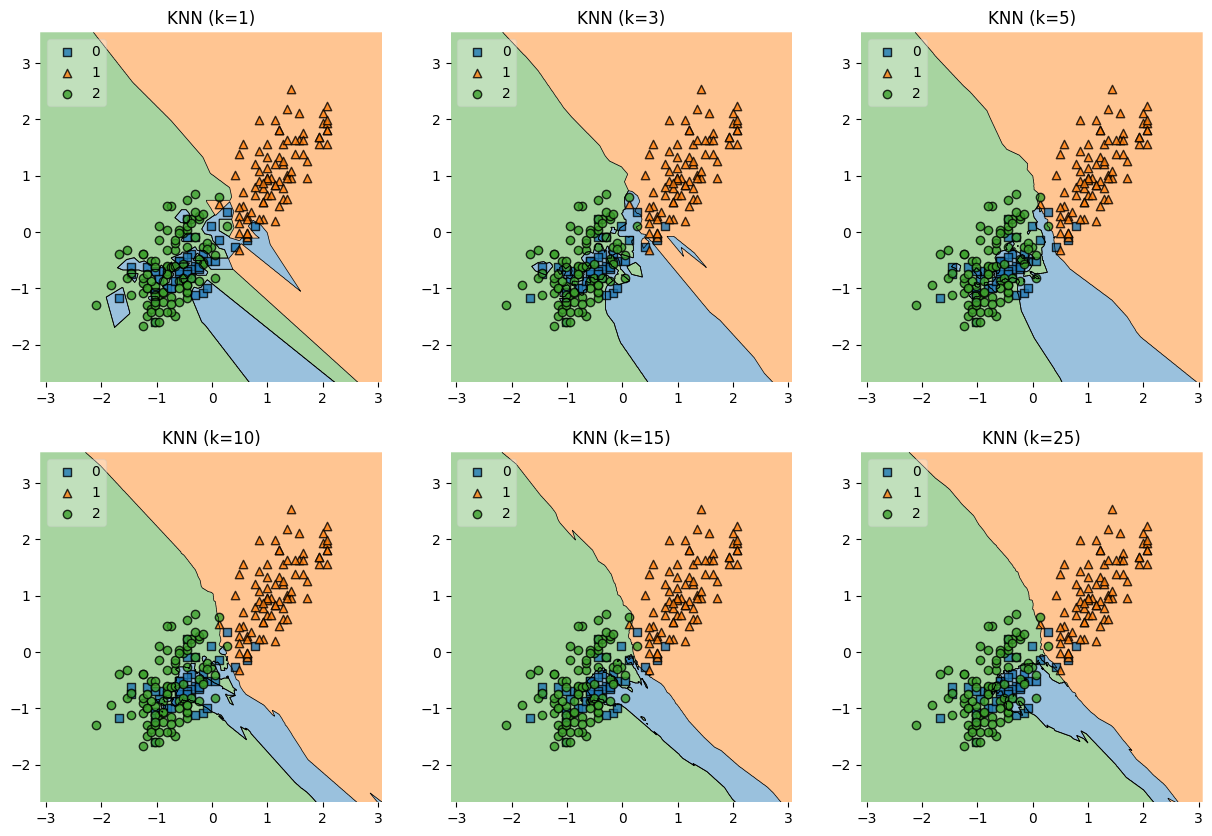

In [ ]:
gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(15,10))

labels = [f'KNN (k={i})' for i in [1, 3, 5, 10, 15, 25]]
for clf, lab, grd in zip(classifiers, labels, itertools.product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[grd[0], grd[1]])
    plot_decision_regions(X=x_train_scaled, y=y_train.to_numpy().astype(int), clf=clf, legend=2, ax=ax)
    plt.title(lab)

plt.show()# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

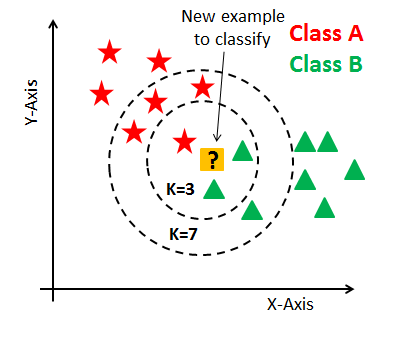

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [18]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
      self.X_train = np.array(X)
      self.y_train = np.array(y)
      pass

    def predict(self, X):
      X = np.array(X)
      predictions = []
      for x in X:
          distances = self.count_distance(x, self.X_train)
          k_indices = np.argsort(distances)[:self.k]
          k_nearest_labels = [self.y_train[i] for i in k_indices]
          most_common = Counter(k_nearest_labels).most_common(1)
          predictions.append(most_common[0][0])
      return np.array(predictions)
      pass

    def count_distance(self, x, y):
      return np.linalg.norm(y - x, axis=1)

      # YOUR CODE HERE
      # ヽ(♡‿♡)ノ

      pass

In [19]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [20]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [21]:
neighbors = [1, 3, 5, 10, 15, 25]
results=[]
df=pd.DataFrame(columns=['NN','Train','Test'])
for n in neighbors:
    knn = KNN(k=n)
    knn.fit(x_train_scaled, y_train)
    y_train_pred = knn.predict(x_train_scaled)
    y_test_pred = knn.predict(x_test_scaled)
    results.append(round(accuracy_score(y_test, y_test_pred),2))
max(results)

0.84

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [22]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [23]:
data.isna().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


Явных пропусков нет, проверим на неявные:

In [53]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [24]:
categories=data.select_dtypes(include=['object', 'category']).columns
for column in categories:
  print(column, data[column].unique())

cut ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
color ['E' 'I' 'J' 'H' 'F' 'G' 'D']
clarity ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


Значения в столбцах совпадают с теми, что указаны по ссылке в описании, так что неявных пропусков не вижу.

In [25]:
data.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [54]:
data.head(5)

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False


Очевидно, самый первый столбец является столбцом айдишников, поэтому он будет бессмыслемен для обучения модели. Остальные столбцы, я бы выкидывать сразу не стала, так как они все исходя из описания влияют на цену бриллианта (да, возможно, потом возникнет проблема мультиколлинеарности, но с ней нужно работать более тщательно).

In [27]:
data=data.drop('Unnamed: 0',axis=1)

In [28]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

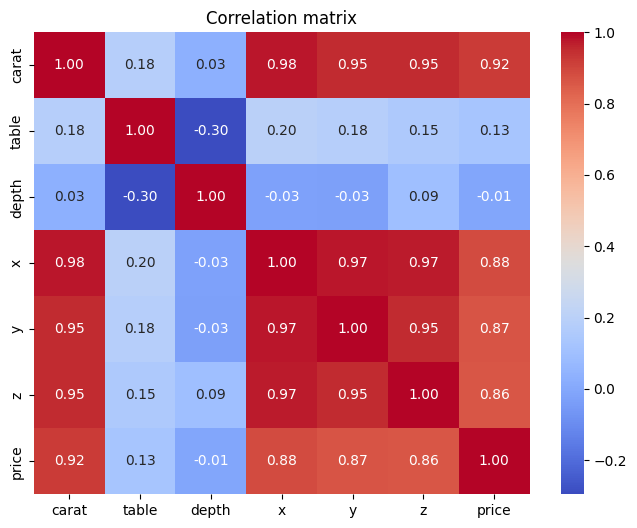

In [29]:
features=['carat','table','depth','x','y','z','price']
correlation_matrix=data[features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

Для наглядности я построила heatmap: видим, что самую высокую корреляцию с ценой имеют карат и x,y,z (длина, ширина и высота бриллианта). Это логично -- чем больше каратность и размер бриллианта, тем выше его цена.

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [30]:
data = pd.get_dummies(data, columns=['cut','color','clarity'], drop_first=True)

**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [31]:
x=data.drop('price',axis=1)
y=data['price']

In [32]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [33]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

При масштабировании признаков все признаки приводятся к одной шкале (у всех среднее значение ноль, стандартное отклонение 1). То есть, например, в нашей ситуации до масштабирования коэффициент w_i при признаке x_i  указывал на то, насколько изменится y при изменении x_i на одну единицу измерения x_i(например, изменение на миллиметр длины бриллианта). А после масштабирования, w_i уже указывает на то, насколько изменится цена после изменения признака на одно стандартное отклонение. То есть теперь с помощью w_i можно понять, какие признаки больше влияют на модель (если после масштабирования коэффициент одного признака больше коэффициента другого, то это означает что первый признак больше влияет на целевую переменную).

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [55]:
model=LinearRegression()
model.fit(x_train,y_train)
print(round(mean_squared_error(model.predict(x_train),y_train),2),round(mean_squared_error(model.predict(x_test),y_test),2))

1290541.91 1244765.44


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [60]:
coefficients=model.coef_
print(coefficients)
mean_abs = np.mean(np.abs(coefficients))
significant_indices = np.where(np.abs(coefficients) > 2 * mean_abs)[0]
feature_names = x.columns.tolist()
if significant_indices.size > 0:
    significant_names = [feature_names[i] for i in significant_vars_indices]
    significant_coefficients = coefficients[significant_indices]

    print("Значительные признаки и их коэффициенты:")
    for name, coef in zip(significant_names, significant_coefficients):
        print(f"{name}: {coef:.2f}")


[ 1.12262051e+04 -6.31199113e+01 -2.70960563e+01 -9.80549238e+02
 -5.63315299e+00 -4.81547644e+01  5.95521080e+02  8.46196258e+02
  7.77769963e+02  7.43301360e+02 -2.17028968e+02 -2.73303976e+02
 -5.00160238e+02 -9.98634669e+02 -1.47608423e+03 -2.38198979e+03
  5.45903730e+03  3.75170967e+03  2.78194055e+03  4.65783431e+03
  4.33672558e+03  5.10133518e+03  5.02829553e+03]
Значительные признаки и их коэффициенты:
carat: 11226.21
clarity_IF: 5459.04
clarity_VS1: 4657.83
clarity_VVS1: 5101.34
clarity_VVS2: 5028.30


Под "на порядок превышают" я поняла как больше чем в два раза.

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

[ 1.122621e+04 -6.312000e+01 -2.710000e+01 -9.805500e+02 -5.630000e+00
 -4.815000e+01  5.955200e+02  8.462000e+02  7.777700e+02  7.433000e+02
 -2.170300e+02 -2.733000e+02 -5.001600e+02 -9.986300e+02 -1.476080e+03
 -2.381990e+03  5.459040e+03  3.751710e+03  2.781940e+03  4.657830e+03
  4.336730e+03  5.101340e+03  5.028300e+03]
[ 9538.47  -103.97   -53.72  -422.29    -0.      -0.      -0.     145.96
    72.19    85.35     0.      -0.    -127.38  -597.72  -977.37 -1763.84
  1350.1      0.    -799.48   819.75   569.27  1182.95  1167.4 ]
[ 1.090013e+04 -6.170000e+01 -2.815000e+01 -8.634300e+02 -1.050000e+00
 -4.453000e+01  6.197500e+02  8.750600e+02  8.043700e+02  7.757200e+02
 -2.048900e+02 -2.615600e+02 -4.818200e+02 -9.757900e+02 -1.442660e+03
 -2.335280e+03  4.851100e+03  3.181140e+03  2.223250e+03  4.079740e+03
  3.764770e+03  4.516170e+03  4.447790e+03]


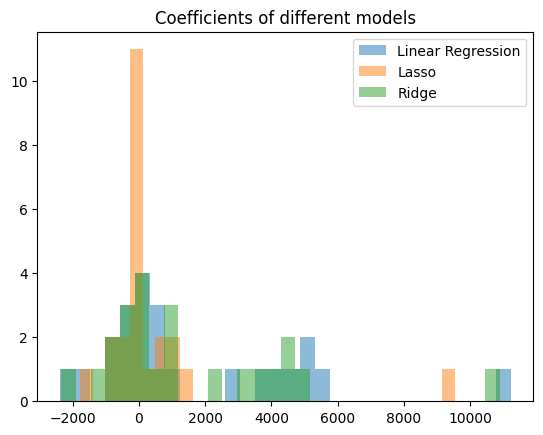

In [67]:
lasso_model=Lasso(alpha=10)
lasso_model.fit(x_train,y_train)
lasso_coefficients=lasso_model.coef_
ridge_model = Ridge(alpha=10)
ridge_model.fit(x_train, y_train)
ridge_coefficients = ridge_model.coef_
print(np.round(coefficients,2))
print(np.round(lasso_coefficients,2))
print(np.round(ridge_coefficients,2))
plt.hist(coefficients,bins=30, alpha=0.5, label='Linear Regression')
plt.hist(lasso_coefficients,bins=30,alpha=0.5,label='Lasso')
plt.hist(ridge_coefficients,bins=30,alpha=0.5, label='Ridge')
plt.title('Coefficients of different models')
plt.legend()

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

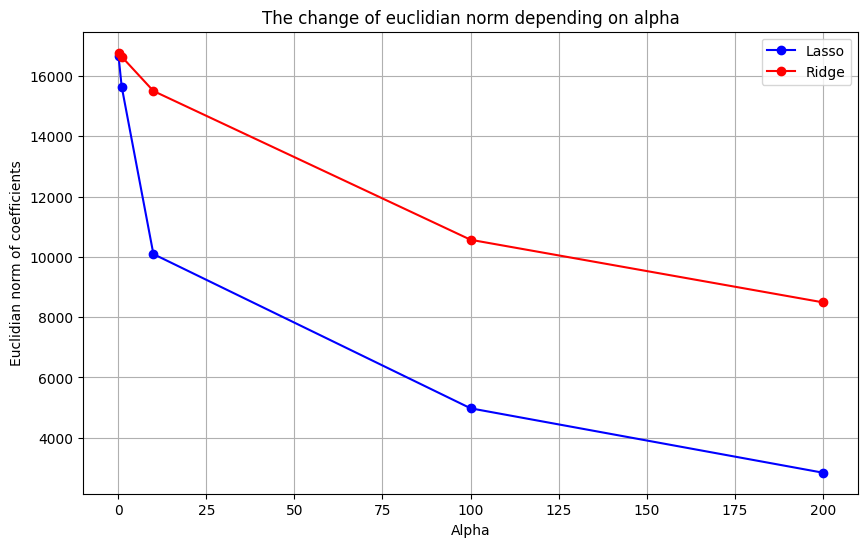

In [66]:
alphas = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(x_train, y_train)
    lasso_norms.append(np.linalg.norm(lasso_model.coef_))
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(x_train, y_train)
    ridge_norms.append(np.linalg.norm(ridge_model.coef_))

plt.figure(figsize=(10, 6))
plt.plot(alphas, lasso_norms, marker='o', label='Lasso', color='blue')
plt.plot(alphas, ridge_norms, marker='o', label='Ridge', color='red')
plt.xlabel('Alpha')
plt.ylabel('Euclidian norm of coefficients')
plt.title('The change of euclidian norm depending on alpha')
plt.legend()
plt.grid()
plt.show()

По графику очевидно, что lasso сильнее занижает норму признаков. Мне кажется, это происходит пототому, что Lasso зануляет наименее информативные признаки, а ridge просто делает их очень маленькими. И как раз поэтому чаще всего выбирают lasso -- при большом количестве признаков она оказывается удобнее, так как просто выкидывает наименее полезные признаки, тем самым упрощая модель.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [80]:
alphas = [0.1,1,10, 100, 200]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(x_train, y_train)
mse_path = lasso_cv.mse_path_
mean_mse = mse_path.mean(axis=1)
best_alpha = lasso_cv.alphas_[np.argmin(mean_mse)]
print(best_alpha)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 695136042.6309967, tolerance: 48476565.465277866
  model = cd_fast.enet_coordinate_descent_gram(


0.1


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [88]:
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)
coefficients = lasso.coef_
df = pd.DataFrame({'Features': x.columns, 'Coefficients': coefficients})
print(df)

no_inf = df[df['Coefficients'] == 0]
inf = df[df['Coefficients'] != 0]

print("Неинформативные признаки:")
print(no_inf['Features'])

print("Информативные признаки:")
print(inf['Features'])

         Features  Coefficients
0           carat  11208.579465
1           depth    -63.796627
2           table    -27.431581
3               x   -976.221745
4               y     -4.967537
5               z    -46.338859
6        cut_Good    585.104454
7       cut_Ideal    835.926825
8     cut_Premium    767.570241
9   cut_Very Good    733.616093
10        color_E   -211.660389
11        color_F   -267.969659
12        color_G   -494.278968
13        color_H   -992.485982
14        color_I  -1468.854625
15        color_J  -2373.586348
16     clarity_IF   5402.201485
17    clarity_SI1   3698.865327
18    clarity_SI2   2729.626817
19    clarity_VS1   4603.898098
20    clarity_VS2   4283.606050
21   clarity_VVS1   5046.456622
22   clarity_VVS2   4974.081915
Неинформативные признаки:
Series([], Name: Features, dtype: object)
Информативные признаки:
0             carat
1             depth
2             table
3                 x
4                 y
5                 z
6          cut_Good


**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [89]:
y_pred = lasso.predict(x_test)
print(round(mean_squared_error(y_test, y_pred),2))


1244347.91


1244765.44 -- это mse линейной регрессии, которое больше средней квадратичной ошибки Lasso. Значит, лучше использовать lasso модель. Почему lasso модель оказалась лучше линейной регрессии: Lasso содержит регуляризацию, которая помогает предотвратить переобучение модели, что решает нашу проблему мультиколлинеарности.